# O algoritmo de Deutsch-Jozsa

Para este módulo do Qiskit na Sala de Aula, os estudantes devem ter um ambiente Python funcionando com os seguintes pacotes instalados:

*   `qiskit` v2.1.0 ou mais recente
*   `qiskit-ibm-runtime` v0.40.1 ou mais recente
*   `qiskit-aer` v0.17.0 ou mais recente
*   `qiskit.visualization`
*   `numpy`
*   `pylatexenc`

Para configurar e instalar os pacotes acima, consulte o guia [Instalar Qiskit](/docs/guides/install-qiskit).
Para executar trabalhos em computadores quânticos reais, os estudantes precisarão configurar uma conta com o IBM Quantum® seguindo os passos no guia [Configure sua conta IBM Cloud](/docs/guides/cloud-setup).

Este módulo foi testado e utilizou quatro segundos de tempo QPU. Esta é apenas uma estimativa. Seu uso real pode variar.

In [ ]:
# Descomente e modifique esta linha conforme necessário para instalar as dependências
#!pip install 'qiskit>=2.1.0' 'qiskit-ibm-runtime>=0.40.1' 'qiskit-aer>=0.17.0' 'numpy' 'pylatexenc'

In [1]:
# from qiskit_aer import Aer

# for backend in Aer.backends():
#     print(backend)

Assista ao passo a passo do módulo pela Dra. Katie McCormick abaixo, ou clique [aqui](https://youtu.be/QcK0GK7DUh8?si=8e0Lmjgylxmgl2y7) para assistir no YouTube.

***

<IBMVideo id="134413695" title="Katie McCormick apresenta um dos primeiros algoritmos quânticos desenvolvidos: o algoritmo de Deutsch e sua extensão, o algoritmo de Deutsch-Jozsa." />

## Introdução

No início dos anos 1980, físicos quânticos e cientistas da computação tinham uma noção vaga de que a mecânica quântica poderia ser aproveitada para fazer computações muito mais poderosas do que computadores clássicos podem fazer. Seu raciocínio era o seguinte: é difícil para um computador clássico simular sistemas quânticos, mas um computador *quântico* deveria ser capaz de fazê-lo mais eficientemente. E se um computador quântico pudesse simular sistemas quânticos de forma mais eficiente, talvez existissem outras tarefas que ele pudesse executar mais eficientemente do que um computador clássico.

A lógica era sólida, mas os detalhes ainda precisavam ser trabalhados. Isso começou em 1985, quando David Deutsch descreveu o primeiro "computador quântico universal." No mesmo artigo, ele forneceu o primeiro exemplo de problema para o qual um computador quântico poderia resolver algo mais eficientemente do que um computador clássico poderia. Este primeiro exemplo teórico agora é conhecido como "algoritmo de Deutsch." A melhoria no algoritmo de Deutsch foi modesta, mas Deutsch trabalhou com Richard Jozsa alguns anos depois para ampliar ainda mais a diferença entre computadores clássicos e quânticos.

Esses algoritmos — o de Deutsch e a extensão de Deutsch-Jozsa — não são particularmente úteis, mas ainda são realmente importantes por algumas razões:

1.  Historicamente, eles foram alguns dos primeiros algoritmos quânticos que demonstraram vencer seus equivalentes clássicos. Compreendê-los pode nos ajudar a entender como o pensamento da comunidade sobre computação quântica evoluiu ao longo do tempo.
2.  Eles podem nos ajudar a entender alguns aspectos da resposta a uma pergunta surpreendentemente sutil: O que dá à computação quântica seu poder? Às vezes, computadores quânticos são comparados a processadores paralelos gigantes que escalam exponencialmente. Mas isso não está totalmente correto. Embora uma parte da resposta a esta pergunta esteja no chamado "paralelismo quântico," extrair o máximo de informação possível em uma única execução é uma arte sutil. Os algoritmos de Deutsch e Deutsch-Jozsa mostram como isso pode ser feito.

Neste módulo, aprenderemos sobre o algoritmo de Deutsch, o algoritmo de Deutsch-Jozsa e o que eles nos ensinam sobre o poder da computação quântica.

## Paralelismo quântico e seus limites

Parte do poder da computação quântica é derivada do "paralelismo quântico," que é essencialmente a capacidade de realizar operações em múltiplas entradas ao mesmo tempo, já que os estados de entrada do qubit podem estar em uma superposição de múltiplos estados classicamente permitidos. NO ENTANTO, embora um circuito quântico possa ser capaz de avaliar múltiplos estados de entrada de uma vez, extrair toda essa informação de uma só vez é impossível.

Para ver o que quero dizer aqui, vamos dizer que temos um bit, $x$ e alguma função aplicada a esse bit, $f(x)$. Existem quatro possíveis funções binárias que levam um único bit para outro único bit:

| $x$ | $f_1(x)$ | $f_2(x)$ | $f_3(x)$ | $f_4(x)$ |
| --- | -------- | -------- | -------- | -------- |
| 0   | 0        | 0        | 1        | 1        |
| 1   | 0        | 1        | 0        | 1        |

Gostaríamos de descobrir qual dessas funções (1-4) nossa $f(x)$ é. Classicamente, precisaríamos executar a função duas vezes — uma vez para $x=0$, uma vez para $x=1$. Mas vamos ver se podemos fazer melhor com um circuito quântico. Podemos aprender sobre a função com a seguinte porta:

<img src=../quantum-parallelism.avif width="50%">

Aqui, a porta $U_f$ calcula $f(x)$, onde $x$ é o estado do qubit 0, e aplica isso ao qubit 1. Então, o estado resultante, $|x\rangle|y\oplus f(x)\rangle$, simplesmente se torna $|x\rangle|f(x)\rangle$ quando $|y\rangle = |0\rangle$. Isso contém toda a informação que precisamos para conhecer a função $f(x)$: o qubit 0 nos diz qual é $x$, e o qubit 1 nos diz qual é $f(x)$. Então, se inicializarmos $|x\rangle = \frac{1}{\sqrt{2}}(|0\rangle+|1\rangle)$, então o estado final de ambos os qubits será: $|y\rangle|x\rangle = \frac{1}{\sqrt{2}}(|f(0)\rangle|0\rangle+|f(1)\rangle|1\rangle)$. Mas como acessamos essa informação?

### 2.1. Teste no Qiskit:

Usando o Qiskit, vamos selecionar aleatoriamente uma das quatro funções possíveis acima e executar o circuito. Então sua tarefa é usar as medições do circuito quântico para aprender a função no menor número possível de execuções.

Neste primeiro experimento e ao longo do módulo, usaremos uma estrutura para computação quântica conhecida como "padrões Qiskit", que divide os fluxos de trabalho nas seguintes etapas:

*   Etapa 1: Mapear entradas clássicas para um problema quântico
*   Etapa 2: Otimizar o problema para execução quântica
*   Etapa 3: Executar usando Primitivos Qiskit Runtime
*   Etapa 4: Pós-processamento e análise clássica

Vamos começar carregando alguns pacotes necessários, incluindo os primitivos Qiskit Runtime. Também selecionaremos o computador quântico menos ocupado disponível para nós.

Há código abaixo para salvar suas credenciais no primeiro uso. Certifique-se de excluir essas informações do notebook após salvá-las no seu ambiente, para que suas credenciais não sejam compartilhadas acidentalmente quando você compartilhar o notebook. Consulte [Configure sua conta IBM Cloud](/docs/guides/initialize-account) e [Inicialize o serviço em um ambiente não confiável](/docs/guides/cloud-setup-untrusted) para mais orientações.

In [67]:
# Carregar o serviço Qiskit Runtime
from qiskit_ibm_runtime import QiskitRuntimeService

# Carregar o primitivo Runtime e sessão
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Sintaxe para primeiro salvar seu token. Exclua essas linhas após salvar suas credenciais.
# QiskitRuntimeService.save_account(channel='ibm_quantum_platform', instance = '', token='', overwrite=True, set_as_default=True)
# service = QiskitRuntimeService(channel='ibm_quantum_platform')

# Carregar credenciais salvas
service = QiskitRuntimeService()

# Use o backend menos ocupado, ou descomente o carregamento de um backend específico como "ibm_brisbane".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits = 127)
#backend = service.backend("ibm_brisbane")
print(backend.name)


sampler = Sampler(mode=backend)

management.get:WARNING:2025-10-16 14:17:58,300: Loading default saved account


ibm_torino


A célula abaixo permitirá que você **alterne entre usar o simulador ou hardware real** ao longo do notebook. Recomendamos executá-la agora:

In [20]:
# Carregar o sampler do backend
from qiskit.primitives import BackendSamplerV2

# Carregar o simulador Aer e gerar um modelo de ruído baseado no backend atualmente selecionado.
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

noise_model = NoiseModel.from_backend(backend)

# Defina um simulador usando Aer e use-o no Sampler.
backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)

# Alternativamente, carregue um backend falso com propriedades genéricas e defina um simulador.
# from qiskit.providers.fake_provider import GenericBackendV2
# backend_gen = GenericBackendV2(num_qubits=18)
# sampler_gen = BackendSamplerV2(backend = backend_gen)

Agora que carregamos os pacotes necessários, podemos prosseguir com o fluxo de trabalho dos padrões Qiskit. Na etapa de mapeamento abaixo, primeiro fazemos uma função que seleciona entre as quatro funções possíveis que levam um único bit para outro único bit.

**Função $f_{1}(x)$**

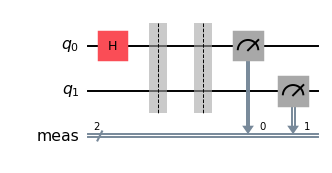

**Função $f_{2}(x)$**

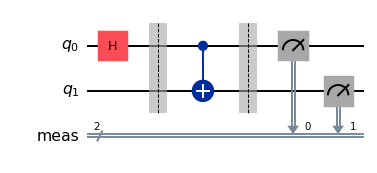

**Função $f_{3}(x)$**

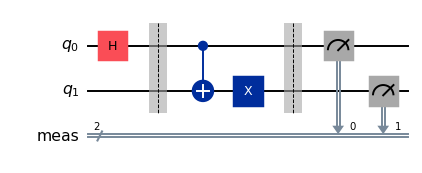

**Função $f_{4}(x)$**

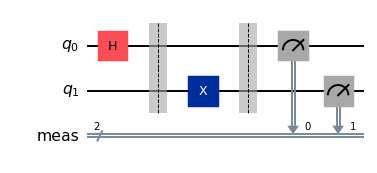

'Circuito Escolhido:'

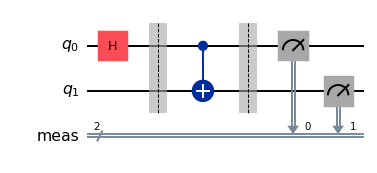

In [68]:
# Etapa 1: Mapear

from qiskit import QuantumCircuit
from matplotlib import pyplot as plt

#qc = QuantumCircuit(2)

def twobit_function(case: int):
    """
    Gerar uma função válida de dois bits como um `QuantumCircuit`.
    """
    if case not in [1, 2, 3, 4]:
        raise ValueError("`case` deve ser 1, 2, 3, ou 4.")

    f = QuantumCircuit(2)
    if case in [2, 3]:
        f.cx(0, 1)
    if case in [3, 4]:
        f.x(1)
    return f

# Gerar e exibir os 4 circuitos para cada função possível
figs = []
for i in range(1, 5):
    qc_temp = QuantumCircuit(2)
    qc_temp.h(0)
    qc_temp.barrier()
    qc_temp.compose(twobit_function(i), inplace=True)
    qc_temp.measure_all()
    figs.append(qc_temp.draw("mpl", scale=.7))

# Exibir todos os circuitos
from IPython.display import Markdown
for fig in enumerate(figs):
    display(Markdown(f"**Função $f_{{{fig[0] + 1}}}(x)$**"))
    display(fig[1])

# Escolher uma das funções para analisar
qc = QuantumCircuit(2)
qc.h(0)
qc.barrier()
qc.compose(twobit_function(2), inplace=True)
qc.measure_all()
display("Circuito Escolhido:" , qc.draw("mpl", scale=.7))

# Podemos converter circuito oráculo (acima) para uma única porta para fins de desenho. caso contrário, o circuito é muito grande para exibir
# blackbox = twobit_function(2).to_gate()  # você pode editar o número dentro de "twobit_function()" para selecionar entre as quatro funções válidas
# blackbox.label = "$U_f$"

No circuito acima, a porta Hadamard "H" leva o qubit 0, que está inicialmente no estado $|0\rangle$, para o estado de superposição $\frac{1}{\sqrt{2}}(|0\rangle+|1\rangle)$. Então, $U_f$ avalia a função $f(x)$ e aplica isso ao qubit 1.

Em seguida, precisamos otimizar e transpilar o circuito para ser executado no computador quântico:

In [77]:
# Etapa 2: Transpilar
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc)

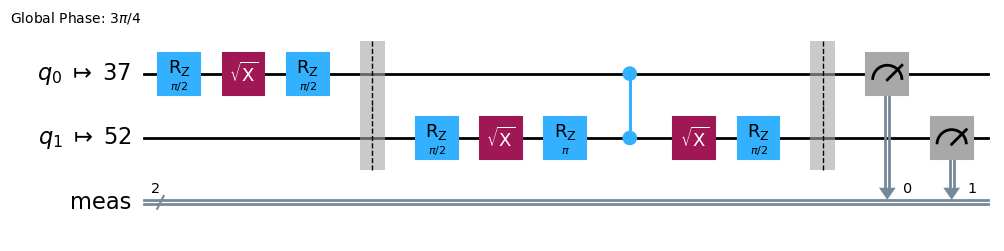

In [78]:
qc_isa.draw("mpl")

Finalmente, executamos nosso circuito transpilado no computador quântico e visualizamos nossos resultados:

In [90]:
# Etapa 3: Executar o trabalho em um computador quântico real ou simulador

job = sampler.run([qc_isa], shots=1024) # descomente esta linha para executar no computador quântico real
jobsim = sampler_sim.run([qc_isa], shots=1024) # descomente esta linha para executar no simulador com ruído
res = job.result()
ressim = jobsim.result()

counts = res[0].data.meas.get_counts()
countssim = ressim[0].data.meas.get_counts()

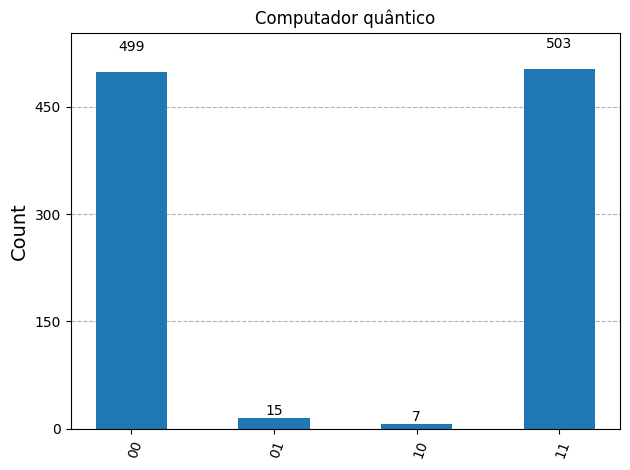

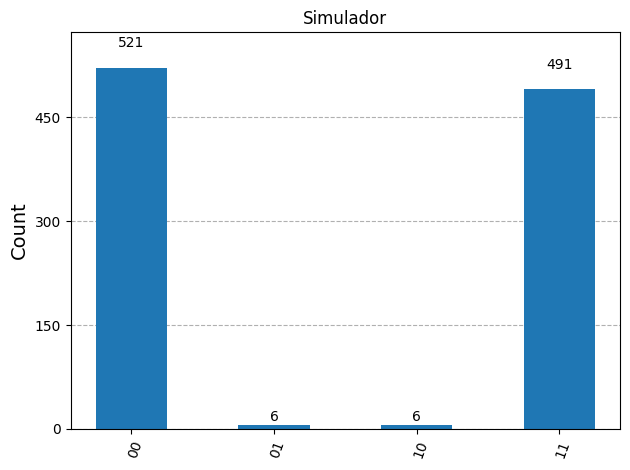

In [93]:
# Etapa 4: Visualizar e analisar resultados

## Análise
from qiskit.visualization import plot_histogram

display(plot_histogram(counts, title="Computador quântico"), plot_histogram(countssim, title="Simulador"))


O acima é um histograma dos nossos resultados. Dependendo do número de shots que você escolheu para executar o circuito na etapa 3 acima, você pode ver uma ou duas barras, representando os estados medidos dos dois qubits em cada shot. Como sempre com o Qiskit e neste notebook, usamos notação "little endian", ou seja, os estados dos qubits 0 até n são escritos em ordem crescente da direita para a esquerda, então o qubit 0 está sempre mais à direita.

Então, porque o qubit 0 estava em um estado de superposição, o circuito avaliou a função para *ambos* $x=0$ e $x=1$ *ao mesmo tempo* — algo que computadores clássicos não podem fazer! Mas o problema vem quando queremos aprender sobre a função $f(x)$ — quando medimos os qubits, nós colapsamos seu estado. Se você selecionar "shots = 1" para executar o circuito apenas uma vez, você verá apenas uma barra no histograma acima, e sua informação sobre a função será incompleta.

#### Teste sua compreensão

Leia a(s) pergunta(s) abaixo, pense sobre sua resposta, então clique no triângulo para revelar a solução.

<details>
  <summary>
    Quantas vezes devemos executar o algoritmo acima para aprender a função $f(x)$? Isso é melhor do que o caso clássico? Você preferiria ter um computador clássico ou quântico para resolver este problema?
  </summary>

  **Resposta:**

  Como a medição irá colapsar a superposição e retornar apenas um valor, precisamos executar o circuito *pelo menos* duas vezes para retornar ambas as saídas da função $f(0)$ e $f(1)$. No melhor caso, isso performa tão bem quanto o caso clássico, onde calculamos tanto $f(0)$ quanto $f(1)$ nas primeiras duas consultas. Mas há uma chance de que precisemos executá-lo mais de duas vezes, já que a medição final é probabilística e pode retornar o mesmo valor $f(x)$ nas primeiras duas vezes. Eu preferiria ter um computador clássico neste caso.
</details>

Então, embora o paralelismo quântico possa ser poderoso quando usado da maneira certa, não é correto dizer que um computador quântico funciona como um processador paralelo clássico massivo. O ato de medição colapsa os estados quânticos, então só podemos acessar uma única saída da computação.

## Algoritmo de Deutsch

Embora o paralelismo quântico sozinho não nos dê uma vantagem sobre computadores clássicos, podemos combiná-lo com outro fenômeno quântico, a interferência, para alcançar uma aceleração. O algoritmo agora conhecido como "algoritmo de Deutsch" é o primeiro exemplo de um algoritmo que consegue isso.

### O problema

Aqui estava o problema:

Dado um bit de entrada, $x = \{0,1\}$, e uma função de entrada $f(x) = \{0,1\}$, determinar se a função é *balanceada* ou *constante*. Ou seja, se for balanceada, então a saída da função é 0 metade do tempo e 1 a outra metade do tempo. Se for constante, então a saída da função é sempre 0 ou sempre 1. Lembre-se da tabela das quatro funções possíveis que levam um único bit para outro único bit:

| $x$ | $f_1(x)$ | $f_2(x)$ | $f_3(x)$ | $f_4(x)$ |
| --- | -------- | -------- | -------- | -------- |
| 0   | 0        | 0        | 1        | 1        |
| 1   | 0        | 1        | 0        | 1        |

A primeira e a última funções, $f_1(x)$ e $f_4(x)$, são constantes, enquanto as duas funções do meio, $f_2(x)$ e $f_3(x)$, são balanceadas.

### O algoritmo

A maneira como Deutsch abordou este problema foi através do "modelo de consulta." No modelo de consulta, a função de entrada ($f_i(x)$ acima) está contida em uma "caixa preta" — não temos acesso direto ao seu conteúdo, mas podemos consultar a caixa preta e ela nos dará a saída da função. Às vezes dizemos que um "oráculo" fornece essa informação. Veja [Lição 1: Algoritmos de Consulta Quântica](/learning/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/introduction) do curso Fundamentos de Algoritmos Quânticos para mais sobre o modelo de consulta.

Para determinar se um algoritmo quântico é mais eficiente que um algoritmo clássico no modelo de consulta, podemos simplesmente comparar o número de consultas que precisamos fazer da caixa preta em cada caso. No caso clássico, para saber se a função contida na caixa preta era balanceada ou constante, precisaríamos consultar a caixa duas vezes para obter tanto $f(0)$ quanto $f(1)$.

No algoritmo quântico de Deutsch, porém, ele encontrou uma maneira de obter a informação com apenas uma consulta! Ele fez um ajuste ao circuito de "paralelismo quântico" acima, de modo que preparou um estado de superposição em *ambos* os qubits, em vez de apenas no qubit 0. Então as duas saídas da função, $f(0)$ e $f(1)$ interferiram para retornar 0 se ambas fossem 0 ou ambas fossem 1 (a função era constante), e retornaram 1 se fossem diferentes (a função era balanceada). Dessa forma, Deutsch pôde diferenciar entre uma função constante e balanceada com uma única consulta.

Aqui está um diagrama de circuito do algoritmo de Deutsch:

<img src="../Deutsch_algo.avif" width="70%">

Para entender como este algoritmo funciona, vamos olhar os estados quânticos dos qubits nos três pontos observados no diagrama acima. Tente trabalhar os estados você mesmo antes de clicar para ver as respostas:

#### Teste sua compreensão

Leia as perguntas abaixo, pense sobre suas respostas, então clique nos triângulos para revelar as soluções.

<details>
  <summary>
    Qual é o estado $|\pi_1\rangle$?
  </summary>

  **Resposta:**

  Aplicar um Hadamard transforma o estado $|0\rangle$ para $\frac{1}{\sqrt{2}}(|0\rangle+|1\rangle)$ e o estado $|1\rangle$ para  $\frac{1}{\sqrt{2}}(|0\rangle-|1\rangle)$. Então, o estado completo se torna: $|\pi_1\rangle = [\frac{|0\rangle-|1\rangle}{\sqrt{2}}][\frac{|0\rangle+|1\rangle}{\sqrt{2}}]$
</details>

<details>
  <summary>
    Qual é o estado $|\pi_2\rangle$?
  </summary>

  **Resposta:**

  Antes de aplicarmos $U_f$, lembre-se do que ela faz. Ela mudará o estado do qubit 1 baseado no estado do qubit 0. Então, faz sentido fatorar o estado do qubit 0: $|\pi_1\rangle = \frac{1}{2} (|0\rangle-|1\rangle)|0\rangle+\frac{1}{2}(|0\rangle-|1\rangle)|1\rangle$. Então, se $f(0)=f(1)$, os dois termos se transformarão da mesma maneira e o sinal relativo entre os dois termos permanece positivo, mas se $f(0)\neq f(1)$, então isso significa que o segundo termo pegará um sinal negativo relativo ao primeiro termo, mudando o estado do qubit 0 de $\frac{1}{\sqrt{2}}(|0\rangle+|1\rangle)$ para $\frac{1}{\sqrt{2}}(|0\rangle-|1\rangle)$. Então:

  $$
  |\pi_2\rangle = \begin{cases}
  \pm[\frac{|0\rangle-|1\rangle}{\sqrt{2}}][\frac{|0\rangle+|1\rangle}{\sqrt{2}}] & \text{se} & f(0) = f(1) \\
  \pm[\frac{|0\rangle-|1\rangle}{\sqrt{2}}][\frac{|0\rangle-|1\rangle}{\sqrt{2}}] &\text{se} & f(0) \neq f(1) \\
  \end{cases}
  $$
</details>

<details>
  <summary>
    Qual é o estado $|\pi_3\rangle$?
  </summary>

  **Resposta:**

  Agora, o estado do qubit 0 é ou $\frac{1}{\sqrt{2}}(|0\rangle+|1\rangle)$ ou $\frac{1}{\sqrt{2}}(|0\rangle-|1\rangle)$, dependendo da função. Aplicar o Hadamard produzirá ou $|0\rangle$ ou $|1\rangle$, respectivamente.

  $$
  |\pi_3\rangle = \begin{cases}
  \pm[\frac{|0\rangle-|1\rangle}{\sqrt{2}}]|0\rangle & \text{se} & f(0) = f(1) \\
  \pm[\frac{|0\rangle-|1\rangle}{\sqrt{2}}]|1\rangle &\text{se} & f(0) \neq f(1) \\
  \end{cases}
  $$
</details>

Olhando através das suas respostas para as perguntas acima, note que algo um pouco surpreendente acontece. Embora $U_f$ não faça nada explicitamente ao estado do qubit 0, porque muda o qubit 1 baseado no estado do qubit 0, pode acontecer que isso cause uma mudança de fase no qubit 0. Isso é conhecido como o fenômeno de "phase-kickback", e é discutido em mais detalhes na [Lição 1: Algoritmos de Consulta Quântica](/learning/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/introduction) do curso Fundamentos de Algoritmos Quânticos.

Agora que entendemos como este algoritmo funciona, vamos implementá-lo com o Qiskit.

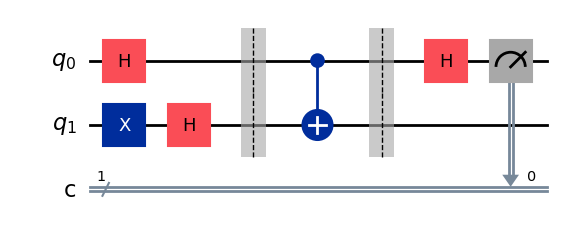

In [94]:
## Algoritmo de Deutsch:

## Etapa 1: Mapear o problema

# primeiro, converter circuito oráculo (acima) para uma única porta para fins de desenho. caso contrário, o circuito é muito grande para exibir
blackbox = twobit_function(
    3
).to_gate()  # você pode editar o número (1-4) dentro de "twobit_function()" para selecionar entre as quatro funções válidas
blackbox.label = "$U_f$"


qc_deutsch = QuantumCircuit(2, 1)

qc_deutsch.x(1)
qc_deutsch.h(range(2))

qc_deutsch.barrier()
qc_deutsch.compose(twobit_function(2), inplace=True)
qc_deutsch.barrier()

qc_deutsch.h(0)
qc_deutsch.measure(0, 0)

qc_deutsch.draw("mpl")

In [95]:
# Etapa 2: Transpilar
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc_deutsch)

In [ ]:
# Etapa 3: Executar o trabalho em um computador quântico real

#job = sampler.run([qc_isa], shots=1)
job = sampler_sim.run([qc_isa], shots=1024) # descomente esta linha para executar no simulador em vez disso
res = job.result()
counts = res[0].data.c.get_counts()

In [ ]:
# Etapa 4: Visualizar e analisar resultados

## Análise
print(counts)
# if "1" in counts:
#     print("balanceada")
# else:
#     print("constante")

{'1': 1020, '0': 4}
balanceada


## O algoritmo de Deutsch-Jozsa

O algoritmo de Deutsch foi um primeiro passo importante na demonstração de como um computador quântico poderia ser mais eficiente do que um computador clássico, mas foi apenas uma melhoria modesta: exigiu apenas uma consulta, comparado a duas no caso clássico. Em 1992, Deutsch e seu colega, Richard Jozsa, estenderam o algoritmo original de dois qubits para mais qubits. O problema permaneceu o mesmo: determinar se uma função é *balanceada* ou *constante*. Mas desta vez, a função vai de $n$ bits para um único bit. Ou a função retorna 0 e 1 um número igual de vezes (é *balanceada*) ou a função retorna sempre 1 ou sempre 0 (é *constante*).

Aqui está um diagrama de circuito do algoritmo:

<img src="../DJ_algo.avif" width="70%">

Este algoritmo funciona da mesma maneira que o algoritmo de Deutsch: o phase-kickback permite ler o estado do qubit 0 para determinar se a função é constante ou balanceada. É um pouco mais complicado de ver do que para o caso do algoritmo de Deutsch de dois qubits, já que os estados incluirão somas sobre os $n$ qubits, e então trabalhar esses estados será deixado como um exercício opcional para você no final do módulo. **O algoritmo retornará uma string de bits de todos 0's se a função for constante, e uma string de bits contendo pelo menos um 1 se a função for balanceada.**

Para ver como o algoritmo funciona no Qiskit, primeiro, precisamos gerar nosso oráculo: a função aleatória que é garantida para ser constante ou balanceada. O código abaixo gerará uma função balanceada 50% do tempo, e uma função constante 50% do tempo. Não se preocupe se você não entender completamente o código — é complicado e não é necessário para nossa compreensão do algoritmo quântico.

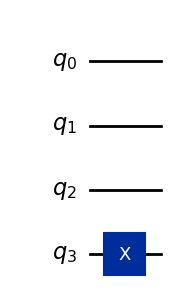

In [ ]:
from qiskit import QuantumCircuit
import numpy as np


def dj_function(num_qubits):
    """
    Criar uma função aleatória de Deutsch-Jozsa.
    """

    qc_dj = QuantumCircuit(num_qubits + 1)
    if np.random.randint(0, 2):
        # Inverter qubits de saída com 50% de chance
        qc_dj.x(num_qubits)
    if np.random.randint(0, 2):
        # retornar circuito constante com 50% de chance.
        return qc_dj

    # Se a declaração "if" acima foi "TRUE" então retornamos a função
    # constante e a função está completa. Se não, prosseguimos criando nossa
    # função balanceada. Tudo abaixo é para produzir a função balanceada:

    # selecionar metade de todos os estados possíveis aleatoriamente:
    on_states = np.random.choice(
        range(2**num_qubits),  # números para amostrar
        2**num_qubits // 2,  # número de amostras
        replace=False,  # garante que estados sejam amostrados apenas uma vez
    )

    def add_cx(qc_dj, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc_dj.x(qubit)
        return qc_dj

    for state in on_states:
        # qc_dj.barrier()  # Barreiras são adicionadas para ajudar a visualizar como as funções são criadas. Podem ser removidas com segurança.
        qc_dj = add_cx(qc_dj, f"{state:0b}")
        qc_dj.mcx(list(range(num_qubits)), num_qubits)
        qc_dj = add_cx(qc_dj, f"{state:0b}")

    # qc_dj.barrier()

    return qc_dj


n = 3  # número de qubits de entrada

oráculo = dj_function(n)

display(oráculo.draw("mpl"))

Esta é a função oráculo, que é balanceada ou constante. Você pode ver olhando para ela se a saída no último qubit depende dos valores colocados nos primeiros $n$ qubits? Se a saída para o último qubit depende dos primeiros $n$ qubits, você pode dizer se essa saída dependente é balanceada ou não?

Podemos dizer se a função é balanceada ou constante olhando para o circuito acima, mas lembre-se, para o propósito deste problema, pensamos nesta função como uma "caixa preta." Não podemos espiar dentro da caixa para olhar o diagrama do circuito. Em vez disso, precisamos consultar a caixa.

Para consultar a caixa, usamos o algoritmo de Deutsch-Jozsa e determinamos se a função é constante ou balanceada:

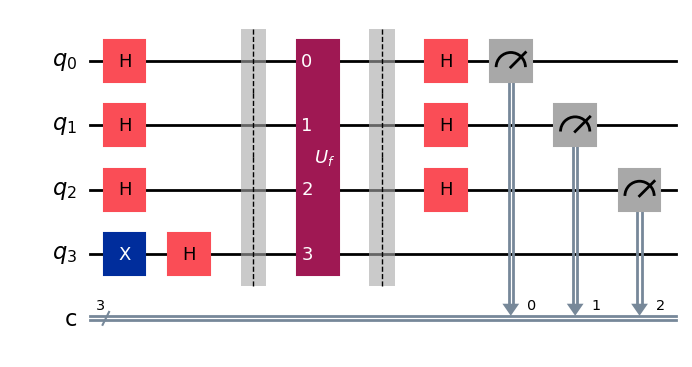

In [ ]:
blackbox = oráculo.to_gate()
blackbox.label = "$U_f$"


qc_dj = QuantumCircuit(n + 1, n)
qc_dj.x(n)
qc_dj.h(range(n + 1))
qc_dj.barrier()
qc_dj.compose(blackbox, inplace=True)
qc_dj.barrier()
qc_dj.h(range(n))
qc_dj.measure(range(n), range(n))
qc_dj.decompose().decompose()


qc_dj.draw("mpl")

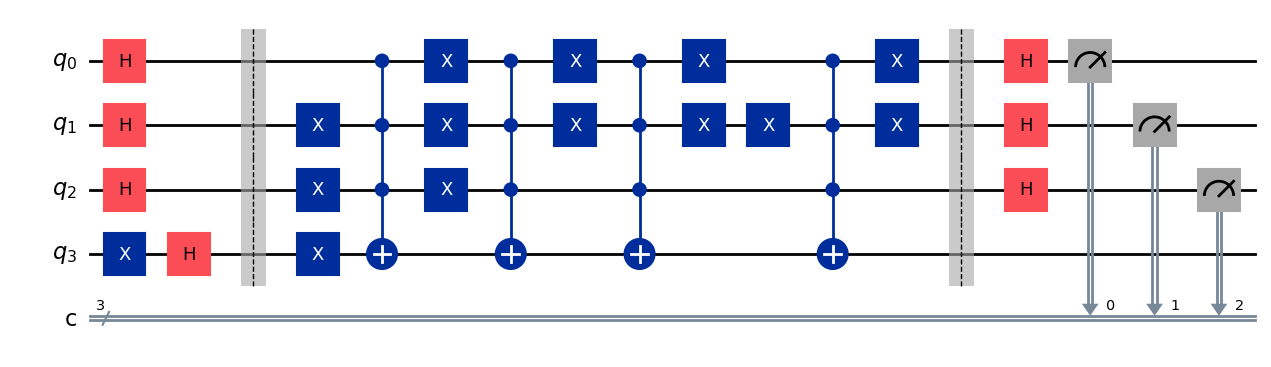

In [ ]:
# Etapa 1: Mapear o problema

qc_dj = QuantumCircuit(n + 1, n)
qc_dj.x(n)
qc_dj.h(range(n + 1))
qc_dj.barrier()
qc_dj.compose(oráculo, inplace=True)
qc_dj.barrier()
qc_dj.h(range(n))
qc_dj.measure(range(n), range(n))

qc_dj.decompose().decompose()


qc_dj.draw("mpl")

In [101]:
# Etapa 2: Transpilar
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc_dj)

In [118]:
# Etapa 3: Executar o trabalho em um computador quântico real

#job = sampler.run([qc_isa], shots=1)
job = sampler_sim.run([qc_isa],shots=1024) # descomente esta linha para executar no simulador em vez disso
res = job.result()
counts = res[0].data.c.get_counts()

In [119]:
# Etapa 4: Visualizar e analisar resultados

## Análise
print(counts)

if (
    "0" * n in counts
):  # O algoritmo D-J retorna todos zeros se a função era constante
    print("constante")
else:
    print("balanceada")  # qualquer coisa diferente de todos zeros significa que a função é balanceada.

{'010': 218, '101': 222, '100': 222, '011': 218, '110': 40, '111': 32, '001': 35, '000': 37}
constante


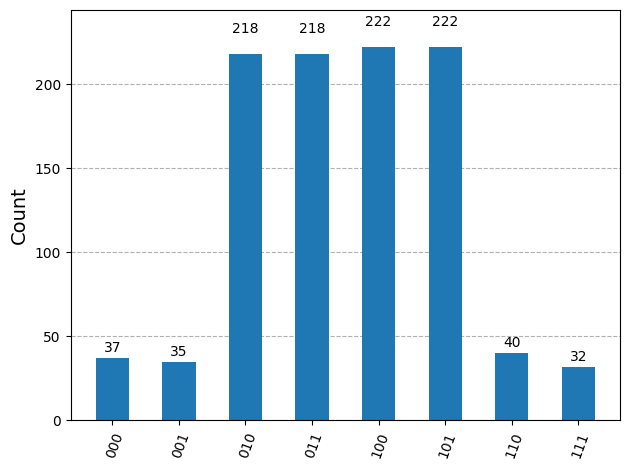

In [120]:
plot_histogram(counts)

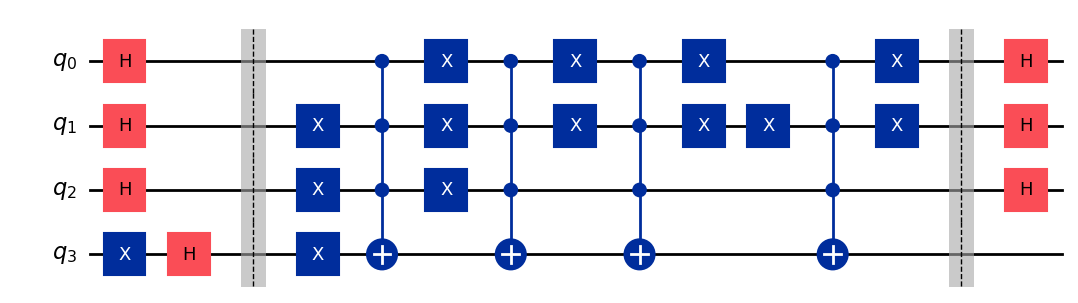

In [ ]:
# Etapa 1: Mapear o problema

qc_dj = QuantumCircuit(n + 1)
qc_dj.x(n)
qc_dj.h(range(n + 1))
qc_dj.barrier()
qc_dj.compose(oráculo, inplace=True)
qc_dj.barrier()
qc_dj.h(range(n))
#qc_dj.measure(range(n), range(n))

qc_dj.decompose().decompose()


qc_dj.draw("mpl")

In [130]:
from qiskit.quantum_info import Statevector

ket0 = [1]
for i in range(2**(n+1)-1):
    ket0.append(0)

print(ket0, len(ket0))
ket0 = Statevector(ket0)



[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] 16


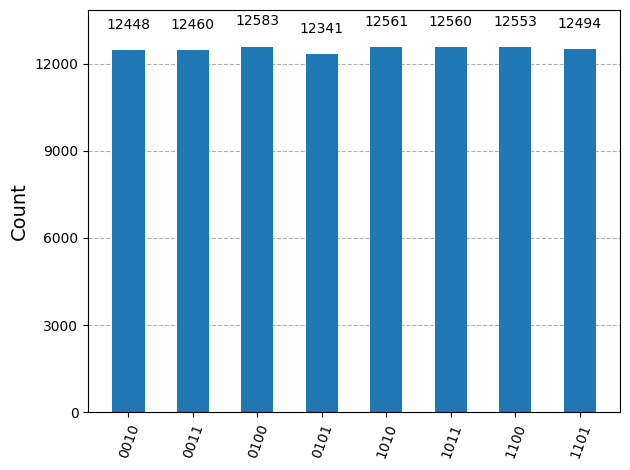

In [131]:
v0 = ket0.evolve(qc_dj)

statistics = v0.sample_counts(100000)
plot_histogram(statistics)

Acima, a primeira linha da saída é a string de bits dos resultados das medições. A segunda linha produz se a string de bits implica que a função era balanceada ou constante. Se a string de bits continha todos zeros, então era constante; se não, era balanceada. Então, com apenas uma única execução do circuito quântico acima, podemos determinar se a função é constante ou balanceada!

#### Teste sua compreensão

Leia as perguntas abaixo, pense sobre suas respostas, então clique nos triângulos para revelar as soluções.

<details>
  <summary>
    Quantas consultas levaria para um computador clássico determinar com 100% de certeza se uma função era constante ou balanceada? Lembre-se, classicamente, uma única consulta só permite aplicar a função a uma única string de bits.
  </summary>

  **Resposta:**

  Existem $2^n$ strings de bits possíveis para verificar, e no pior caso, você precisaria testar $2^n/2+1$ delas. Por exemplo, se a função fosse constante, e você continuasse medindo "1" como a saída da função, então você não poderia ter certeza de que era verdadeiramente constante até verificar mais da metade dos resultados. Antes disso, você poderia ter sido apenas muito azarado para continuar medindo "1" em uma função balanceada. É como lançar uma moeda repetidamente e sempre cair cara. É improvável, mas não impossível.
</details>

<details>
  <summary>
    Como sua resposta acima mudaria se você apenas tivesse que medir até que um resultado (balanceado ou constante) fosse mais provável que o outro? Quantas consultas levaria neste caso?
  </summary>

  **Resposta:**

  Neste caso, você poderia apenas medir duas vezes. Se as duas medições fossem diferentes, você sabe que a função é balanceada. Se as duas medições fossem iguais, então poderia ser balanceada, ou poderia ser constante. A probabilidade de que seja balanceada com este conjunto de medições é: $\frac{1}{2}\frac{2^n /2 - 1}{2^n-1}$. Isso é menor que 1/2, então é mais provável que a função seja constante neste caso.
</details>

Então, o algoritmo de Deutsch-Jozsa demonstrou uma aceleração exponencial sobre um algoritmo clássico *determinístico* (um que retorna a resposta com 100% de certeza), mas nenhuma aceleração significativa sobre um *probabilístico* (um que retorna um resultado que é *provável* de ser a resposta correta).

### O problema de Bernstein - Vazirani

Em 1997, Ethan Bernstein e Umesh Vazirani usaram o algoritmo de Deutsch-Jozsa para resolver um problema mais específico e restrito comparado ao problema de Deutsch-Jozsa. Em vez de simplesmente tentar distinguir entre duas classes diferentes de funções, como no caso D-J, Bernstein e Vazirani usaram o algoritmo de Deutsch-Jozsa para realmente aprender uma string codificada em uma função. Aqui está o problema:

A função $f:\{0,1\}^n \rightarrow \{0,1\}$ ainda leva uma string de $n$ bits e produz um único bit. Mas agora, em vez de prometer que a função é balanceada ou constante, agora prometemos que a função é o produto escalar entre a string de entrada $x$ e alguma string secreta de $n$ bits $s$, módulo 2. (Este produto escalar módulo 2 é chamado de "produto escalar binário.") O problema é descobrir qual é a string secreta de $n$ bits.

Escrito de outra forma, recebemos uma função caixa-preta $f: \{0,1\}^n \rightarrow \{0,1\}$ que satisfaz $f(x) = s \cdot x$ para alguma string $s$, e queremos aprender a string $s$.

Vamos dar uma olhada em como o algoritmo D-J resolve este problema:

1.  Primeiro, uma porta Hadamard é aplicada aos $n$ qubits de entrada, e uma porta NOT mais um Hadamard é aplicada ao qubit de saída, fazendo o estado:

$$
|\Psi\rangle = |-\rangle_{n} \otimes |+\rangle_{n-1} \otimes |+\rangle_{n-2} \otimes ... \otimes |+\rangle_0
$$

O estado dos qubits 1 até $n$ pode ser escrito mais simplesmente como uma soma sobre todos os $2^n$ estados base de $n$ qubits $|00...00\rangle, |00...01\rangle, |000...11\rangle, ..., |111...11\rangle$. Chamamos o conjunto desses estados base de $\Sigma^n$. (Veja [Fundamentos de Algoritmos Quânticos](/learning/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-jozsa-algorithm) para mais detalhes.)

$$
|\Psi\rangle = |-\rangle \otimes \frac{1}{\sqrt{2^n}}\sum\limits_{x \in \Sigma^n}{|x\rangle}
$$

2.  Em seguida, a porta $U_f$ é aplicada aos qubits. Esta porta pegará os primeiros n qubits como entrada (que agora estão em uma superposição igual de todas as strings possíveis de n bits) e aplica a função $f(x)=s \cdot x$ ao qubit de saída, de modo que este qubit agora está no estado: $ |- \oplus f(x)\rangle$. Graças ao mecanismo de phase kickback, o estado deste qubit permanece inalterado, mas alguns dos termos no estado do qubit de entrada pegam um sinal negativo:

$$
|\Psi\rangle = |-\rangle \otimes \frac{1}{\sqrt{2^n}}\sum\limits_{x \in \Sigma^n}{(-1)^{f(x)}|x\rangle}
$$

3.  Agora, o próximo conjunto de Hadamards é aplicado aos qubits 0 até $n-1$. Acompanhar os sinais negativos neste caso pode ser complicado. É útil saber que aplicar uma camada de Hadamards a $n$ qubits em um estado base padrão $|x\rangle$ pode ser escrito como:

$$
H^{\otimes n} |x\rangle = \frac{1}{\sqrt{2^n}}\sum\limits_{y \in \Sigma^n}{(-1)^{x \cdot y}|y\rangle}
$$

Então o estado se torna:

$$
|\Psi\rangle = |-\rangle \otimes \frac{1}{2^n}\sum\limits_{x \in \Sigma^n}\sum\limits_{y \in \Sigma^n}{(-1)^{(s \cdot x) + (x \cdot y)}|y\rangle}
$$

4.  O próximo passo é medir os primeiros $n$ bits. Mas o que vamos medir? Acontece que o estado acima se simplifica para:  $|\Psi\rangle = |-\rangle \otimes |s\rangle$, mas isso está longe de ser óbvio. Se você gostaria de seguir a matemática, veja o curso [Fundamentos de Algoritmos Quânticos](/learning/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-jozsa-algorithm#the-bernstein-vazirani-problem) de John Watrous. O ponto é, porém, que o mecanismo de phase kickback leva aos qubits de entrada estarem no estado $|s\rangle$. Então, para descobrir qual era a string secreta $s$, você simplesmente precisa medir os qubits!

#### Teste sua compreensão

Leia as perguntas abaixo, pense sobre suas respostas, então clique nos triângulos para revelar as soluções.

<details>
  <summary>
    Verifique que o estado da Etapa 3 acima é de fato o estado $|s\rangle$ para o caso especial de $n=1$.
  </summary>

  **Resposta:**

  Quando você escreve explicitamente as duas somatórias, você deve obter um estado com quatro termos (vamos omitir o estado de saída $|-\rangle$ para isso):

  $$
  |\Psi\rangle = \frac{1}{2}[|0\rangle + (-1)^s |0\rangle + |1\rangle + (-1)^{(s+1)} |1\rangle]
  $$

  Se $s=0$, então os dois primeiros termos se somam construtivamente e os dois últimos termos se cancelam, deixando-nos com $|\Psi\rangle = |0\rangle$. Se $s=1$, então os dois últimos termos se somam construtivamente e os dois primeiros termos se cancelam, deixando-nos com $|\Psi\rangle = |1\rangle$. Então, em qualquer caso, $|\Psi\rangle = |s\rangle$. Esperançosamente este caso mais simples lhe dá uma noção de como o caso geral com $n$ qubits funciona: todos os termos que não são $|s\rangle$ interferem e desaparecem, deixando apenas o estado $|s\rangle$.
</details>

<details>
  <summary>
    Como o mesmo algoritmo pode resolver tanto os problemas de Bernstein-Vazirani quanto de Deutsch-Jozsa? Para entender isso, pense sobre funções de Bernstein-Vazirani, que são da forma $f(x) = s \cdot x$. Essas funções também são funções de Deutsch-Jozsa? Ou seja, determine se funções dessa forma satisfazem a promessa do problema de Deutsch-Jozsa: que elas são *constantes* ou *balanceadas*. Como isso nos ajuda a entender como o mesmo algoritmo resolve dois problemas diferentes?
  </summary>

  **Resposta:**

  Toda função de Bernstein-Vazirani da forma $f(x) = s \cdot x$ também satisfaz a promessa do problema de Deutsch-Jozsa: se s=00...00, então a função é constante (sempre retorna 0 para toda string x). Se s é qualquer outra string, então a função é balanceada. Então, aplicar o algoritmo de Deutsch-Jozsa a uma dessas funções resolve simultaneamente ambos os problemas! Ele retorna a string, e se essa string é 00...00 então sabemos que é constante; se há pelo menos um "1" na string, sabemos que é balanceada.
</details>

Também podemos verificar que este algoritmo resolve com sucesso o problema de Bernstein-Vazirani testando-o experimentalmente. Primeiro, criamos a função B-V que vive dentro da caixa preta:

In [ ]:
# Etapa 1: Mapear o problema


def bv_function(s):
    """
    Criar uma função de Bernstein-Vazirani a partir de uma string de 1s e 0s.
    """
    qc = QuantumCircuit(len(s) + 1)
    for index, bit in enumerate(reversed(s)):
        if bit == "1":
            qc.cx(index, len(s))
    return qc


display(bv_function("1000").draw("mpl"))

<Image src="/learning/images/modules/computer-science/deutsch-jozsa/extracted-outputs/45449a26-0bd0-4244-87be-3309937955b9-0.avif" alt="Output of the previous code cell" />

In [ ]:
string = "1000"  # string secreta que vamos fingir que não conhecemos ou não temos acesso
n = len(string)

qc = QuantumCircuit(n + 1, n)
qc.x(n)
qc.h(range(n + 1))
qc.barrier()
# qc.compose(oráculo, inplace = True)
qc.compose(bv_function(string), inplace=True)
qc.barrier()
qc.h(range(n))
qc.measure(range(n), range(n))

qc.draw("mpl")

<Image src="/learning/images/modules/computer-science/deutsch-jozsa/extracted-outputs/0cf6f2bc-3b5e-46d2-ab82-1a190e77c42b-0.avif" alt="Output of the previous code cell" />

In [ ]:
# Etapa 2: Transpilar
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc)

In [ ]:
# Etapa 3: Executar o trabalho em um computador quântico real

job = sampler.run([qc_isa], shots=1)
# job = sampler_sim.run([qc_isa],shots=1) # descomente esta linha para executar no simulador em vez disso
res = job.result()
counts = res[0].data.c.get_counts()

In [ ]:
# Etapa 4: Visualizar e analisar resultados

## Análise
print(counts)

{'0000': 1}


Então, com apenas uma única consulta, o algoritmo de Deutsch-Jozsa retornará a string $s$ usada na função: $f(x)=x \cdot s$ quando aplicamos ao problema de Bernstein-Vazirani. Com um algoritmo clássico, seria necessário $n$ consultas para resolver o mesmo problema.

## Conclusão

Esperamos que ao examinar esses exemplos simples, tenhamos dado a você uma melhor intuição de como computadores quânticos são capazes de aproveitar superposição, emaranhamento e interferência para alcançar seu poder sobre computadores clássicos.

O algoritmo de Deutsch-Jozsa tem uma importância histórica enorme porque foi o primeiro a demonstrar qualquer aceleração sobre um algoritmo clássico, mas foi apenas uma aceleração polinomial. O algoritmo de Deutsch-Jozsa é apenas o começo da história.

Depois que eles usaram o algoritmo para resolver seu problema, Bernstein e Vazirani usaram isso como base para um problema mais complicado e recursivo chamado *problema de amostragem de Fourier recursiva*. Sua solução ofereceu uma aceleração super-polinomial sobre algoritmos clássicos. E mesmo antes de Bernstein e Vazirani, Peter Shor já havia criado seu famoso algoritmo que permitiu computadores quânticos fatorar números grandes exponencialmente mais rápido do que qualquer algoritmo clássico poderia. Esses resultados, coletivamente, mostraram a promessa empolgante de futuros computadores quânticos, e incentivaram físicos e engenheiros a tornar esse futuro uma realidade.

## Questões (2,0 pontos)


### Conceitos críticos

*   os algoritmos de Deutsch e Deutsch-Jozsa usam paralelismo quântico combinado com interferência para encontrar uma resposta para um problema mais rápido do que um computador clássico pode.
*   o mecanismo de phase kickback é um fenômeno quântico contraintuitivo que transfere operações em um qubit para a fase de outro qubit. Os algoritmos de Deutsch e Deutsch-Jozsa utilizam este mecanismo.
*   O algoritmo de Deutsch-Jozsa oferece uma aceleração polinomial sobre qualquer algoritmo clássico determinístico.
*   O algoritmo de Deutsch-Jozsa pode ser aplicado a um problema diferente, chamado problema de Bernstein-Vazirani, para encontrar uma string oculta codificada em uma função.

### Verdadeiro/falso (0,5 ponto)

1.  V/F O algoritmo de Deutsch é um caso especial do algoritmo de Deutsch-Jozsa onde a entrada é um único qubit.
2.  V/F Os algoritmos de Deutsch e Deutsch-Jozsa usam superposição e interferência quânticas para alcançar sua eficiência.
3.  V/F O algoritmo de Deutsch-Jozsa requer múltiplas avaliações de função para determinar se uma função é constante ou balanceada.
4.  V/F O "algoritmo de Bernstein-Vazirani" é na verdade o mesmo que o algoritmo de Deutsch-Jozsa, aplicado a um problema diferente.
5.  V/F O algoritmo de Bernstein-Vazirani pode encontrar múltiplas strings secretas simultaneamente.

### Resposta  (0,5 ponto)

1.  Quanto tempo levaria para um algoritmo clássico resolver o problema de Deutsch-Jozsa no pior caso?

2.  Quanto tempo levaria para um algoritmo clássico resolver o problema de Bernstein-Vazirani? Que aceleração o algoritmo DJ oferece neste caso?

3.  Descreva o mecanismo de phase-kickback e como ele funciona para resolver os problemas de Deutsch-Jozsa e Bernstein-Vazirani.

### Problema desafio (1,0 ponto)

1.  O algoritmo de Deutsch-Jozsa: Lembre-se de que você teve uma pergunta acima pedindo para trabalhar os estados intermediários de qubit $\pi_1$ e $\pi_2$ do algoritmo de Deutsch. Faça o mesmo para os estados intermediários de $n+1$ qubits $\pi_1$ e $\pi_2$ do algoritmo de Deutsch-Jozsa, para o caso específico de que $n=2$. Então, verifique que $\pi_3 = |-\rangle \otimes \sum\limits_{x_0...x_n}(-1)^{f(x_0...x_n)}|x_0 ... x_n\rangle$, novamente, para o caso específico de que $n=2$.

# Problemas (8,0 pontos)

## Problemas para o Algoritmo de Deutsch-Jozsa

1. **(1,0 ponto)** Implemente manualmente um oráculo balanceado de 4 qubits, explicando cada etapa da sua construção. Depois, verifique no circuito principal se o algoritmo consegue distinguir corretamente entre funções balanceadas e constantes.

2. **(1,0 ponto)** Altere o número de qubits do algoritmo para 5. Crie e justifique exemplos de oráculos: dois balanceados diferentes e um constante. Mostre os resultados das medidas e explique a razão física da saída encontrada.

3. **(1,5 ponto)** Execute o algoritmo de Deutsch-Jozsa no simulador clássico, simulador com ruído e em hardware real. Compare as distribuições de saída, identificando erros ou ruídos e propondo estratégias para mitigação. Documente diferenças entre execuções.

4. **(1,0 ponto)** O algoritmo de Deutsch-Jozsa depende da promessa de que a função é balanceada ou constante. Proponha e implemente uma função que quebra essa promessa e analise como o algoritmo se comporta neste cenário.

## Problemas para o Algoritmo de Bernstein-Vazirani

1. **(1,0 ponto)** Implemente manualmente um oráculo para o Bernstein-Vazirani com string secreta ‘1101’. Explique toda a lógica de construção do oráculo, rode o circuito e verifique se o algoritmo retorna corretamente a string secreta.

2. **(1,0 ponto)** Configure o experimento com 6 qubits e uma string secreta de sua escolha. Documente o circuito construído e faça uma análise da quantidade de consultas necessárias no modelo clássico e no modelo quântico para recuperar todos os bits.

3. **(0,75 ponto)** Adicione ruído ao modelo de simulação e varie os níveis de erro. Analise a fidelidade dos resultados do Bernstein-Vazirani com diferentes intensidades de ruído. Discuta estratégias para minimizar os erros e compare com as limitações do hardware real.

4. **(0,75 ponto)** Desenvolva uma visualização dos estados dos qubits após cada etapa do algoritmo (Hadamard, aplicação do oráculo, medida final). Compare a evolução para diferentes strings secretas e explique com base nos princípios da superposição e interferência.

© IBM Corp., 2017-2025